In [22]:
# from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

# pd.set_option("display.precision", 10)
# pd.set_option('display.float_format', lambda x: f'{x:.12e}')

In [ ]:
def generate_Table(Tabelle:pd.DataFrame, captionIN:str, labelIN:str):
    # Probleme: \cdot 10^-1; , statt . ; Nachkommastellen chekcken, Title unten?
    latex = Tabelle.to_latex(
        index=False,
        bold_rows=False,
        escape=False,
        float_format="{:.2e}".format,
        decimal=',', #hier macht stress
        column_format=("l"*(len(Tabelle.columns.to_list()))), # L eft, C enter, R ight
        header=Tabelle.columns.to_list(),
        caption=captionIN,
        label="tab:"+labelIN,
        position="H"
    )

    for i in range(-12, 13):
        if i < 0:
            old_str = f"e{i:03d}"
            new_str = f"$\cdot 10^{{{i}}}$"
        elif i == 0: 
            old_str = "e+00"
            new_str = ""
        elif i == 1:
            old_str = "e+01"
            new_str = "$\cdot 10$"
        elif i > 1:
            old_str = f"e{i:02d}"
            new_str = f"$\, \cdot 10^{{{i}}}$"
        latex = latex.replace(old_str, new_str)

    return (latex)

def gewichteter_Mittelwert(daten, fehler):
    """Berechnet den gewichteten Mittelwert der gegebenen Arrays.
    daten = np.array 
    fehler = np.array
    returns [Mittelwert, Fehler]"""
    
    w = 1/(fehler)**2
    omega_bar_w = (np.sum(w*daten)) / (np.sum(w))
    del_omega_bar_w = 1 / np.sqrt(np.sum(w))
    return [omega_bar_w, del_omega_bar_w]

# Formeln für Quadratisches bla

def a_hat(x, y):
    return (np.sum(x**2)*np.sum(y) - np.sum(x)*np.sum(x*y)) / (len(x) * np.sum(x**2) - (np.sum(x))**2)

def b_hat(x, y):
    return (len(x) * np.sum(x*y) - (np.sum(x) * np.sum(y)))/(len(x) * np.sum(x**2) - (np.sum(x))**2) 

def s_ (x, y):
    return np.sqrt(((1)/(len(x)-2)) * (np.sum(y - (a_hat(x, y) + b_hat(x, y) * x)))**2)

def a_delta (x, y):
    return s_(x, y) * np.sqrt( (np.sum(x**2)) / (len(x)*np.sum(x**2) - np.sum(x)**2))

def b_delta(x, y):
    return s_(x, y) * np.sqrt( len(x) / (len(x)*np.sum(x**2) - np.sum(x)**2))

def b_simpel(x, y):
    return (1 * np.sum(x*y)) / np.sum(x**2)

def Streuung_simpel(x, y):
    """Streuungswert s für Geraden ohne Achsenverschiebung."""
    return np.sqrt((1 / (len(x) - 1)) * np.sum((y - (b_hat(x, y) * x))**2))

def Streuung(x, y):
    """Streuungswert s für Geraden mit Achsenverschiebung."""
    return np.sqrt((1 / (len(x) - 2)) * np.sum((y - (a_hat(x, y) + b_hat(x, y) * x))**2))

def delta_b(x, s):
    return  s * np.sqrt(len(x) / (len(x) * np.sum(x*2) - np.sum(x)*2))


<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3091334207.py:19: SyntaxWarning: invalid escape sequence '\c'
  new_str = f"$\cdot 10^{{ {i} }}$"
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3091334207.py:25: SyntaxWarning: invalid escape sequence '\c'
  new_str = "$\cdot 10$"
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3091334207.py:28: SyntaxWarning: invalid escape sequence '\c'
  new_str = f"$\cdot 10^{{ {i} }}$"


In [ ]:
# Laden und Ordnen der Daten
for sheet in range(1,5):
    messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung"+str(sheet))
    messdaten = messdaten.drop(columns=["Einstellungen"])
    messdaten.sort_values(by="U(V)", inplace=True)  # Sortiere die Daten nach Spannung

    # Wiederstand berechnen
    messdaten[r"Widerstand ($\Omega$)"] = messdaten["U(V)"] / messdaten["I(mA)"]  # Berechne den Widerstand

    # Fehler berechnen
    messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
    messdaten[r"$\Delta I$"] = messdaten["I(mA)"].abs() * 0.015 + 0.1e-3
    messdaten[r"$\Delta \Omega$"] = np.sqrt((messdaten[r"$\Delta U$"]/messdaten["I(mA)"])**2 + ((messdaten["U(V)"] * messdaten[r"$\Delta I$"])/(messdaten["I(mA)"]**2))**2)

    # Gewichteter Mittelwert 
    messdaten_NN = messdaten_NN[pd.notna(messdaten_NN)] # Messdaten bereinigen 
    messdaten_NN = messdaten_NN[messdaten_NN["Widerstand ($\\Omega$)"] != 0]  # Nullen löschen
    w = 1/(messdaten_NN[r"$\Delta \Omega$"].to_numpy())**2
    omega = messdaten_NN[r"Widerstand ($\Omega$)"].to_numpy()
    omega_bar_w = (np.sum(w*omega)) / (np.sum(w))
    del_omega_bar_w = 1 / np.sqrt(np.sum(w)) # Fehler

    # print("Messung ", sheet, end=' ')
    # print("Mittler gewichteter Wiederstand ", omega_bar_w, end=' ')
    # print("Fehler d. Wiedrstandes: ", del_omega_bar_w)

    if False: # Tabellen Printen
        cols = ['U(V)', '$\Delta U$', 'I(mA)', '$\Delta I$', 'Widerstand ($\Omega$)', '$\Delta \Omega$']
        # messdaten_tex = messdaten.drop(columns=['Wiederstand'])[cols]
        messdaten_tex = messdaten[cols]
        print(generate_Table(messdaten_tex, "Messreihe " + str(sheet), "Messreihe"+str(sheet)))

    # Plotten
    if False:
        fig, ax = plt.subplots(dpi=600)
        ax.errorbar(messdaten["U(V)"], messdaten["I(mA)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
        ax.plot(messdaten["U(V)"], messdaten["I(mA)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

        ax.set_xlabel(r"U (V)")
        ax.set_ylabel(r"I (mA)")

        # ax.set_xlim(1, 3)
        # ax.set_ylim(-1, 20)
        # ax.hlines(y=0, xmin=min(messdaten["U(V)"]), xmax=max(messdaten["U(V)"]), colors="k")
        # ax.vlines(x=0, ymin=min(messdaten["I(mA)"]), ymax=max(messdaten["I(mA)"]), colors="k")

        # ax.legend()
        ax.grid()
        plt.show()

        # messdaten.plot(x=r"U(V)", y=r"I(mA)", kind="scatter", legend=True, grid=True)

\begin{table}[H]
\caption{Messreihe 1}
\label{tab:Messreihe1}
\begin{tabular}{llllll}
\toprule
U(V) & $\Delta U$ & I(mA) & $\Delta I$ & Widerstand ($\Omega$) & $\Delta \Omega$ \\
\midrule
-9,81 & 5,91$\cdot 10^{ -2 }$ & -6,84$\cdot 10$ & 1,03 & 1,43$\cdot 10^{ -1 }$ & 2,32$\cdot 10^{ -3 }$ \\
-8,01 & 5,01$\cdot 10^{ -2 }$ & -5,52$\cdot 10$ & 8,28$\cdot 10^{ -1 }$ & 1,45$\cdot 10^{ -1 }$ & 2,36$\cdot 10^{ -3 }$ \\
-5,97 & 3,98$\cdot 10^{ -2 }$ & -4,09$\cdot 10$ & 6,14$\cdot 10^{ -1 }$ & 1,46$\cdot 10^{ -1 }$ & 2,40$\cdot 10^{ -3 }$ \\
-3,89 & 2,95$\cdot 10^{ -2 }$ & -2,66$\cdot 10$ & 3,99$\cdot 10^{ -1 }$ & 1,46$\cdot 10^{ -1 }$ & 2,46$\cdot 10^{ -3 }$ \\
-2,01 & 2,00$\cdot 10^{ -2 }$ & -1,38$\cdot 10$ & 2,07$\cdot 10^{ -1 }$ & 1,46$\cdot 10^{ -1 }$ & 2,62$\cdot 10^{ -3 }$ \\
0,00 & 1,00$\cdot 10^{ -2 }$ & 0,00 & 1,00$\cdot 10^{ -4 }$ & NaN & NaN \\
2,01 & 2,00$\cdot 10^{ -2 }$ & 1,36$\cdot 10$ & 2,04$\cdot 10^{ -1 }$ & 1,48$\cdot 10^{ -1 }$ & 2,66$\cdot 10^{ -3 }$ \\
4,04 & 3,02$\cdot 

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\O'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\O'
<>:27: SyntaxWarning: invalid escape sequence '\D'
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3083787193.py:27: SyntaxWarning: invalid escape sequence '\D'
  cols = ['U(V)', '$\Delta U$', 'I(mA)', '$\Delta I$', 'Widerstand ($\Omega$)', '$\Delta \Omega$']
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3083787193.py:27: SyntaxWarning: invalid escape sequence '\D'
  cols = ['U(V)', '$\Delta U$', 'I(mA)', '$\Delta I$', 'Widerstand ($\Omega$)', '$\Delta \Omega$']
C:\Users\oskar\AppData\Local\Temp\ipykernel_18840\3083787193.py:27: SyntaxWarning: invalid escape sequence '\O'
  cols = ['U(V)', '$\Delta U$', 'I(mA)', '$\Delta I$', 'Wi

6.902648135999163


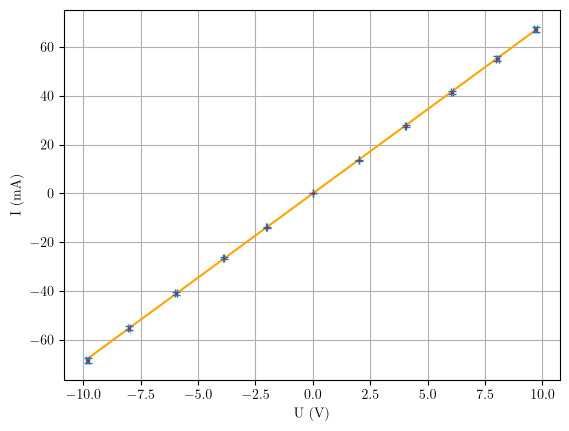

In [ ]:
# Ausgleichsgerade Plotten Messung 1
messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung1")
messdaten = messdaten.drop(columns=["Einstellungen"])

# Fehler berechnen
messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
messdaten[r"$\Delta I$"] = messdaten["I(mA)"].abs() * 0.015 + 0.1e-3

# Lin fit machen 
werte_Gerade = np.array([np.min(messdaten["U(V)"]), np.max(messdaten["U(V)"])])
steigung = b_simpel(messdaten["U(V)"], messdaten["I(mA)"])
print(steigung)

# Fehler aus lin fit berechnen

# Plotten 
fig, ax = plt.subplots()
ax.plot(werte_Gerade, werte_Gerade*(steigung) , color="orange")
ax.errorbar(messdaten["U(V)"], messdaten["I(mA)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
ax.plot(messdaten["U(V)"], messdaten["I(mA)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

ax.set_xlabel(r"U (V)")
ax.set_ylabel(r"I (mA)")
ax.grid()
plt.show()

>=5.5: 
a =  32.66337490763288
b =  6.215656418639113
<=-5.5: 
a =  -32.038892770221345
b =  6.197322337748893
<= 2.5 & >= -2.5: 
a =  -0.1686210623413945
b =  19.28881639633719


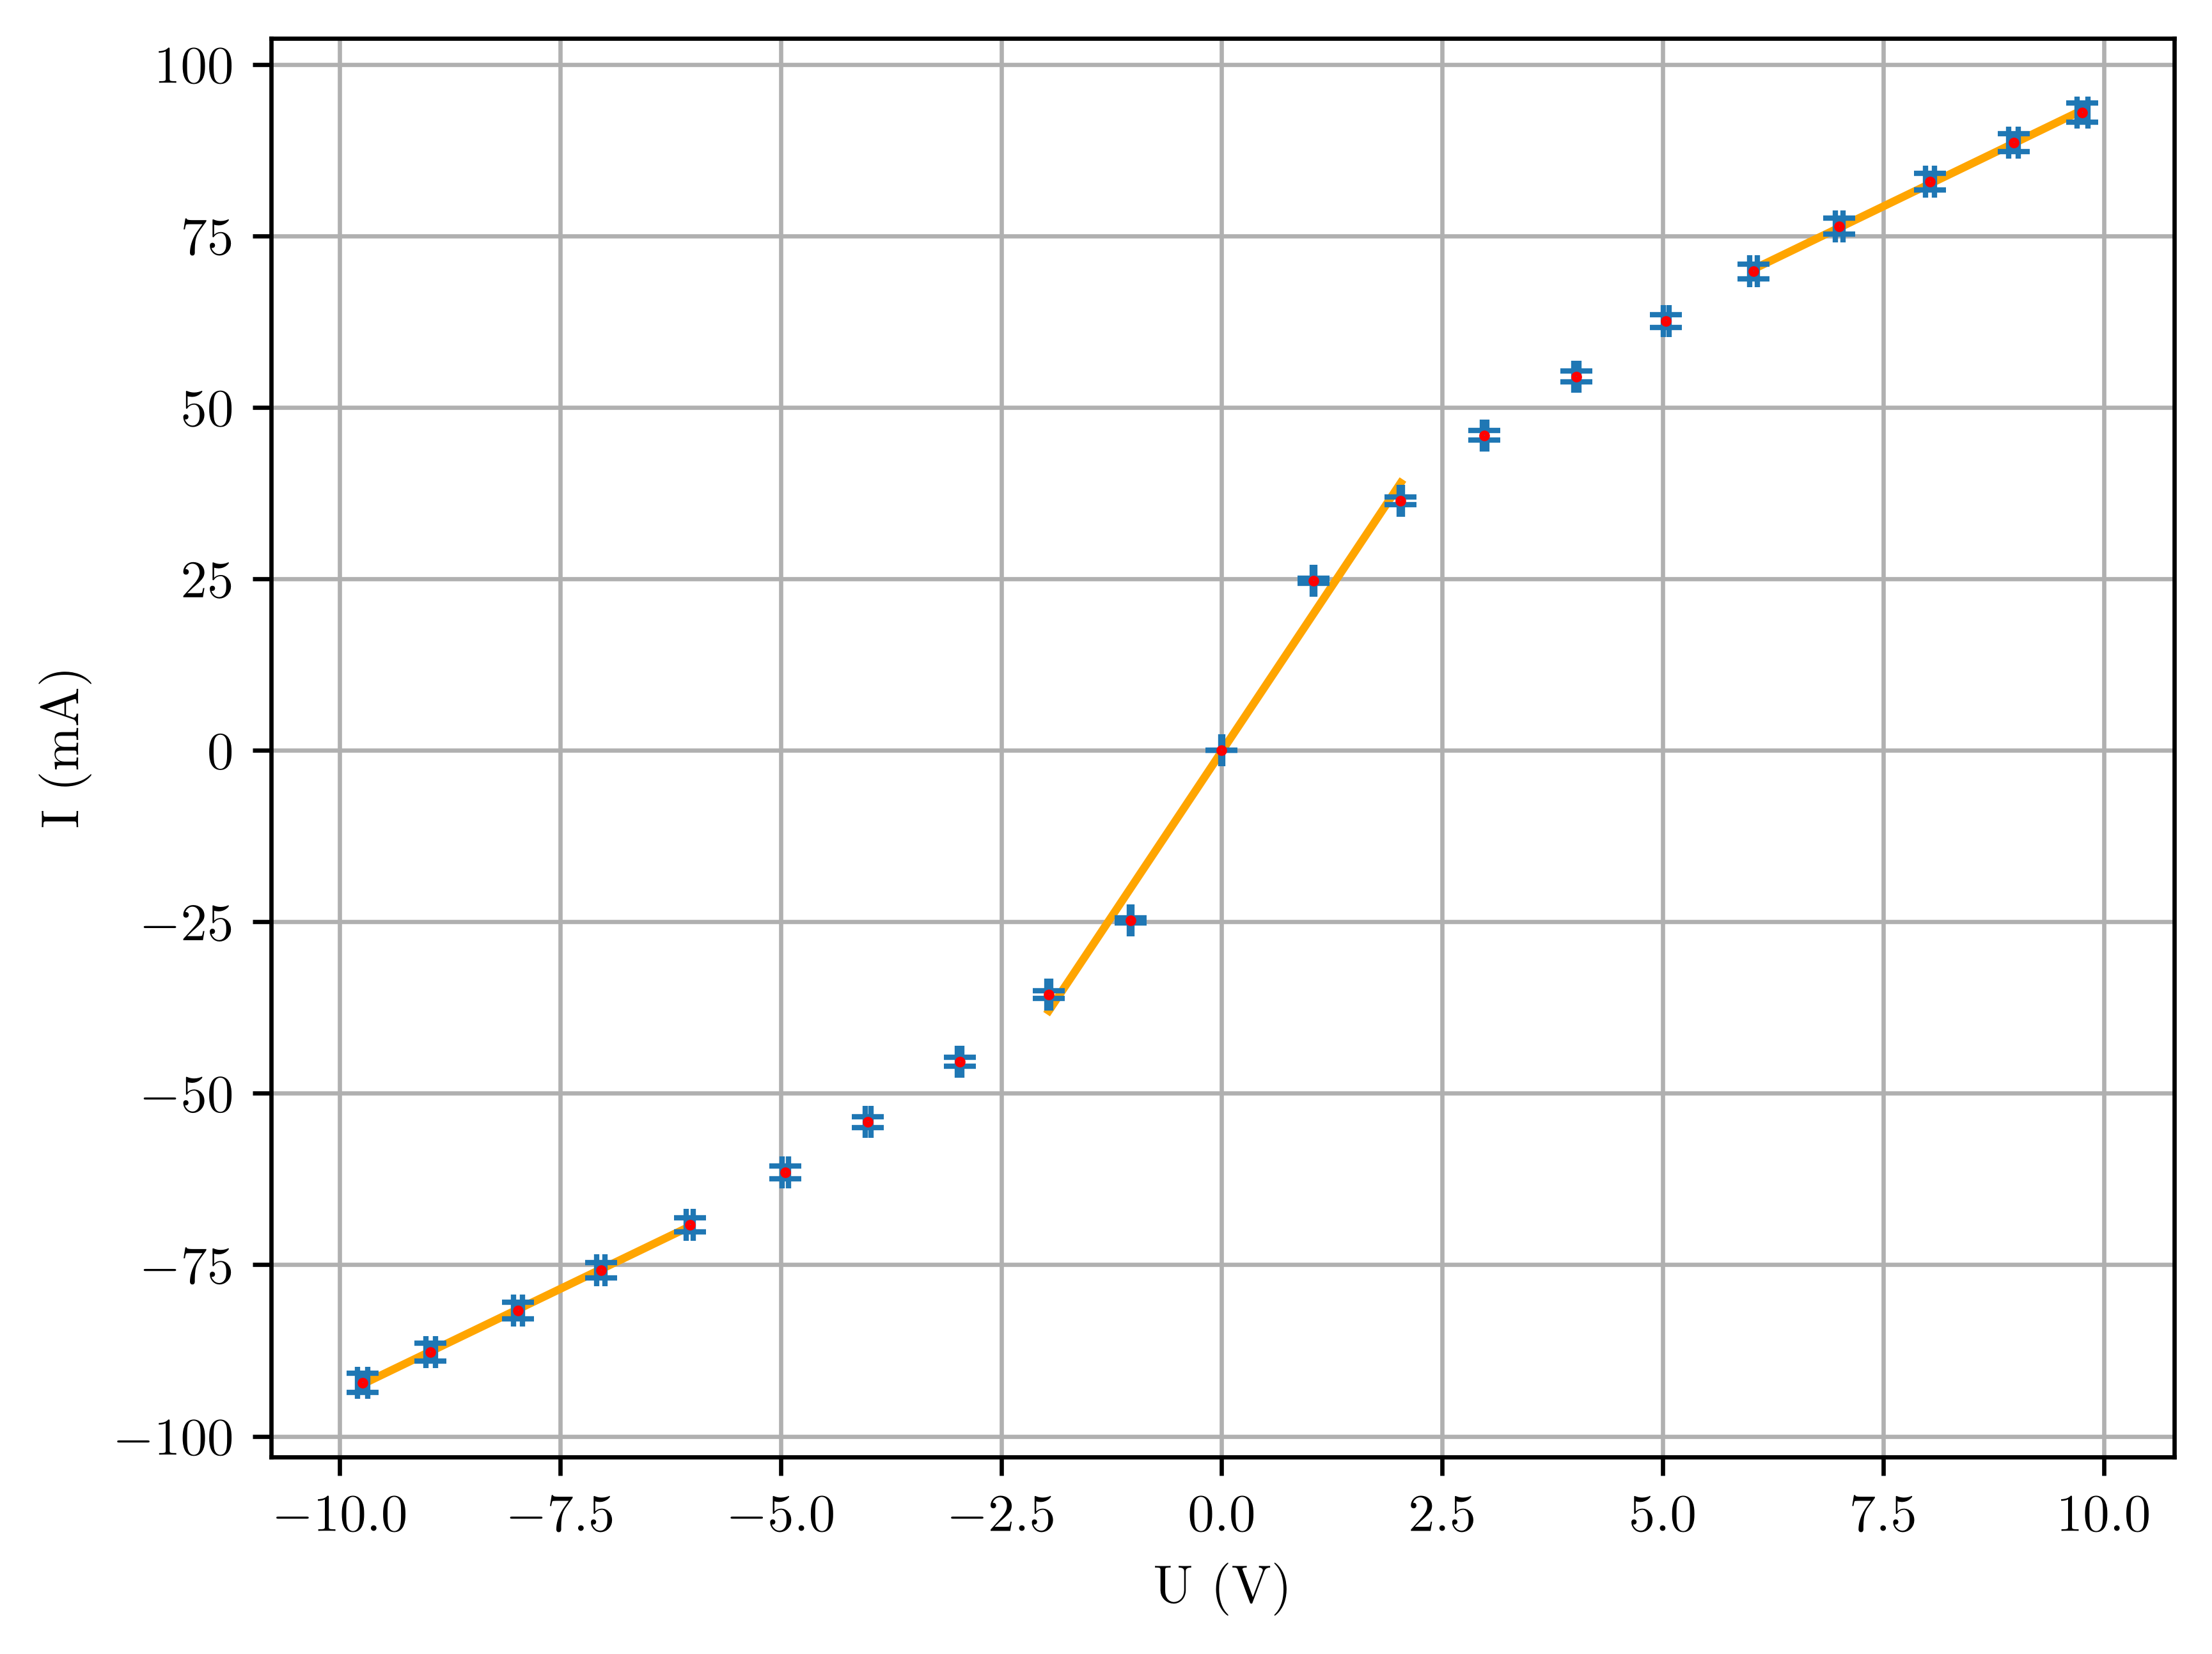

In [125]:
# Ausgleichsgerade Plotten Messung 1
messdaten = pd.read_excel("V45.xlsx", sheet_name="Messung2")
messdaten = messdaten.drop(columns=["Einstellungen"])
messdaten.sort_values(by="U(V)", inplace=True)  # Sortiere die Daten nach Spannung

# Fehler berechnen
messdaten[r"$\Delta U$"] = messdaten["U(V)"].abs() * 0.005 + 0.01
messdaten[r"$\Delta I$"] = messdaten["I(mA)"].abs() * 0.015 + 0.1e-3

# letzte gerade 
messdaten_Teil1 = messdaten[messdaten["U(V)"] >= 5.5]
werte_Gerade_Teil1 = np.array([np.min(messdaten_Teil1["U(V)"]), np.max(messdaten_Teil1["U(V)"])])
a1 = a_hat(messdaten_Teil1["U(V)"], messdaten_Teil1["I(mA)"])
b1 = b_hat(messdaten_Teil1["U(V)"], messdaten_Teil1["I(mA)"])

print(">=5.5: ")
print("a = ", a1)
print("b = ", b1)


# erste gerade 
messdaten_Teil2 = messdaten[messdaten["U(V)"] <= -5.5]
werte_Gerade_Teil2 = np.array([np.min(messdaten_Teil2["U(V)"]), np.max(messdaten_Teil2["U(V)"])])
a2 = a_hat(messdaten_Teil2["U(V)"], messdaten_Teil2["I(mA)"])
b2 = b_hat(messdaten_Teil2["U(V)"], messdaten_Teil2["I(mA)"])

print("<=-5.5: ")
print("a = ", a2)
print("b = ", b2)

# mittlere gerade 
messdaten_Teil3 = messdaten[messdaten["U(V)"] <= 2.5]
messdaten_Teil3 = messdaten_Teil3[messdaten_Teil3["U(V)"] >= -2.5]
werte_Gerade_Teil3 = np.array([np.min(messdaten_Teil3["U(V)"]), np.max(messdaten_Teil3["U(V)"])])
a3 = a_hat(messdaten_Teil3["U(V)"], messdaten_Teil3["I(mA)"])
b3 = b_hat(messdaten_Teil3["U(V)"], messdaten_Teil3["I(mA)"])

print("<= 2.5 & >= -2.5: ")
print("a = ", a3)
print("b = ", b3)



# Plotten 
fig, ax = plt.subplots(dpi=600)
ax.plot(werte_Gerade_Teil1, werte_Gerade_Teil1*(b1)+a1 , color="orange")
ax.plot(werte_Gerade_Teil2, werte_Gerade_Teil2*(b2)+a2 , color="orange")
ax.plot(werte_Gerade_Teil3, werte_Gerade_Teil3*(b3)+a3 , color="orange")


ax.errorbar(messdaten["U(V)"], messdaten["I(mA)"], xerr=messdaten[r"$\Delta U$"], yerr=messdaten[r"$\Delta I$"], fmt=',', capsize=3)
ax.plot(messdaten["U(V)"], messdaten["I(mA)"], '.', label="Messung " + str(sheet), color="red", markersize=2)

ax.set_xlabel(r"U (V)")
ax.set_ylabel(r"I (mA)")
ax.grid()
plt.show()